## Лабораторная работа 5
### Графы


№ 1
(2 балла)
В примере алгоритма поиска в ширину из лекции
(https://cloud.mail.ru/public/9yCy/LitbGAfEg) структура данных граф представлена
словарем. Переделайте этот пример, заменив словарь на реализацию класса Graph из
лекционных материалов.


№ 2
(2 балла)
Реализуйте программу, которая по заданному в виде списка смежности графу строит
обращённый граф (тоже в виде списка смежности). Обращённый граф получается
изменением направления всех рёбер исходного графа. Используйте класс Graph из
лекционных материалов.

In [3]:
from collections import deque

class Vertex:
    def __init__(self, key):
        self.id = key
        self.connectedTo = {}

    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight

    def __str__(self):
        return str(self.id) + ' connectedTo: ' + str([x.id for x in self.connectedTo])

    def getConnections(self):
        return self.connectedTo.keys()

    def getId(self):
        return self.id

    def getWeight(self, nbr):
        return self.connectedTo[nbr]


class Graph:
    def __init__(self):
        self.vertList = {}
        self.numVertices = 0

    def addVertex(self, key):
        self.numVertices = self.numVertices + 1
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex

    def getVertex(self, n):
        if n in self.vertList:
            return self.vertList[n]
        else:
            return None

    def __contains__(self, n):
        return n in self.vertList

    def addEdge(self, f, t, cost=0):
        if f not in self.vertList:
            self.addVertex(f)
        if t not in self.vertList:
            self.addVertex(t)
        self.vertList[f].addNeighbor(self.vertList[t], cost)

    def getVertices(self):
        return self.vertList.keys()

    def __iter__(self):
        return iter(self.vertList.values())

def person_is_seller(name):
      return name[0] == 'a'

graph = Graph()
graph.addVertex('you')
graph.addVertex('bob')
graph.addVertex('alice')
graph.addVertex('claire')
graph.addVertex('anuj')
graph.addVertex('peggy')
graph.addVertex('thom')
graph.addVertex('jonny')

graph.addEdge('you', 'alice')
graph.addEdge('you', 'bob')
graph.addEdge('you', 'claire')


graph.addEdge('bob', 'anuj')
graph.addEdge('bob', 'peggy')

graph.addEdge('alice', 'peggy')

graph.addEdge('claire', 'thom')
graph.addEdge('claire', 'jonny')



def search(name):
    search_queue = deque()
    start_vertex = graph.getVertex(name)
    search_queue += start_vertex.getConnections()
    searched = set()

    while search_queue:
        person = search_queue.popleft()
        person_id = person.getId()

        if person_id not in searched:
            if person_is_seller(person_id):
                print(person_id + " is a mango seller!")
                return True
            else:
                search_queue += person.getConnections()
                searched.add(person_id)
    return False

search("you")


alice is a mango seller!


True

![Alt text](img.png)

In [14]:
g = Graph()
for i in range(4):
    g.addVertex(i)

g.addEdge(0, 1)
g.addEdge(0, 2)
g.addEdge(1, 3)
g.addEdge(2, 1)

def inverse(graph):
    inverseGraph = Graph()

    for v in graph.getVertices():
        inverseGraph.addVertex(v)

    for v in graph.getVertices():
        vertex_obj = graph.getVertex(v)

        neighbors = vertex_obj.connectedTo

        for to_vertex_obj in neighbors:
            to_id = to_vertex_obj.getId()
            from_id = v
            inverseGraph.addEdge(to_id, from_id)


    return inverseGraph

inverseGraph = inverse(g)
for i in range(4):
    print(inverseGraph.getVertex(i))






0 connectedTo: []
1 connectedTo: [0, 2]
2 connectedTo: [0]
3 connectedTo: [1]


№ 3
(4 балла)
Пусть у вас имеется следующий рецепт блинов: одно яйцо, одна чашка блинной смеси, одна
столовая ложка растительного масла и 3/4 чашки молока. Чтобы нажарить блинов, вам
нужно разогреть сковородку, смешать вместе все ингредиенты и выливать смесь по ложке
на горячую сковороду. Когда блин начинает пузыриться, переверните его и дождитесь, пока
нижняя сторона не станет золотистой. Перед тем, как приступить к поеданию блинов,
полейте их сиропом. Весь процесс показан в виде графа.
![Alt text](img_1.png) <br>
Напишите программу, которая при помощи поиска в глубину (Depth-first search, DFS)
проведет топологическую сортировку представленного графа и выдаст вариант корректной
последовательности шагов. Например:<br>
![image.png](img_2.png)
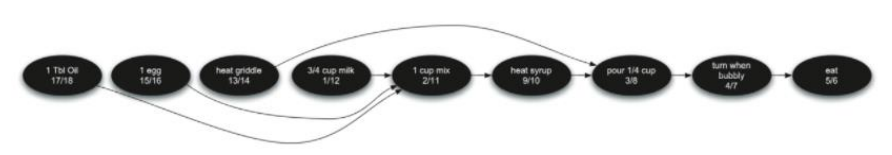

In [15]:

def topoSort(graph):

    indegree = { id: 0 for id in graph.getVertices() }
    for v in graph.getVertices():
        vertex_obj = graph.getVertex(v)
        for nbr_obj in vertex_obj.connectedTo:
            indegree[nbr_obj.getId()] += 1

    queue = deque()
    for vid, deg in indegree.items():
        if deg == 0:
            queue.append(vid)

    res = []

    while queue:
        top = queue.popleft()
        res.append(top)
        for nbr_obj in graph.getVertex(top).connectedTo:
            nbr_id = nbr_obj.getId()
            indegree[nbr_id] -= 1
            if indegree[nbr_id] == 0:
                queue.append(nbr_id)
    return res







g = Graph()
g.addVertex('3/4 cup of milk')
g.addVertex('1 egg')
g.addVertex('1 oil')
g.addVertex('1 cup mix')
g.addVertex('heat syrup')
g.addVertex('heat griddle')
g.addVertex('pour 1/4 cup')
g.addVertex('turn when bubbly')
g.addVertex('eat')

g.addEdge('3/4 cup of milk', '1 cup mix')
g.addEdge('1 egg', '1 cup mix')
g.addEdge('1 oil', '1 cup mix')
g.addEdge('1 cup mix', 'heat syrup')
g.addEdge('heat griddle', 'pour 1/4 cup')
g.addEdge('heat syrup', 'eat')
g.addEdge('1 cup mix', 'pour 1/4 cup')
g.addEdge('pour 1/4 cup', 'turn when bubbly')
g.addEdge('turn when bubbly', 'eat')



order = topoSort(g)
print(order)


['3/4 cup of milk', '1 egg', '1 oil', 'heat griddle', '1 cup mix', 'heat syrup', 'pour 1/4 cup', 'turn when bubbly', 'eat']


№ 4
(5 баллов)
У вас имеется список городов и набор автобусных маршрутов между ними. Маршруты
однонаправленные, т.е. маршрут вида «город А – город Б» означает, что можно поехать из
города А в город Б, а обратного проезда нет.
Пользователь вводит два города. Ваша программа должна определить минимальный по
количеству километров возможный путь от первого до второго города, или сообщение, что
пути между городами нет. Нужно вывести как количество километров, так и получившейся
путь.
Для решения задачи используйте алгоритм Дейкстры и класс Graph из лекционных
материалов. Список городов и маршрутов возьмите согласно вашему варианту. Расстояние
между городами найдите в интернете самостоятельно.
Также необходимо нарисовать граф вашего варианта (например, здесь
https://graphonline.ru/) и приложить его в ваш отчет.
Вариант 1.
Города:
Белово, Ленинск-Кузнецкий, Киселевск, Гурьевск, Мыски, Кемерово, Новосибирск.
Маршруты:
Белово – Ленинск-Кузнецкий
Ленинск-Кузнецкий – Киселевск
Белово – Киселевск
Белово – Гурьевск
Гурьевск – Киселевск
Ленинск-Кузнецкий – Мыски
Киселевск – Кемерово
Кемерово – Новосибирск
Мыски – Новосибирск

![image.png](graph.png)

In [4]:
g = Graph()
g.addVertex('Белово')
g.addVertex('Ленинск-Кузнецкий')
g.addVertex('Киселевск')
g.addVertex('Гурьевск')
g.addVertex('Мыски')
g.addVertex('Кемерово')
g.addVertex('Новосибирск')


g.addEdge('Белово', 'Ленинск-Кузнецкий', 41)
g.addEdge('Ленинск-Кузнецкий', 'Киселевск', 95)
g.addEdge('Ленинск-Кузнецкий', 'Мыски', 191)
g.addEdge('Белово', 'Киселевск', 66)
g.addEdge('Белово', 'Гурьевск', 31)
g.addEdge('Гурьевск', 'Киселевск', 97)
g.addEdge('Киселевск','Кемерово', 175)
g.addEdge('Кемерово','Новосибирск', 265)
g.addEdge('Мыски','Новосибирск', 422)

v = g.getVertex('Белово')
print(v)
print(len(v.getConnections()))


def dijkstra(graph, start_id, end_id):
    costs = {v: float('inf') for v in graph.getVertices()}
    costs[start_id] = 0

    parents = {v: None for v in graph.getVertices()}

    processed = set()

    def find_lowest_cost_node(costs):
        lowest_cost = float('inf')
        lowest_node = None
        for node in costs:
            if costs[node] < lowest_cost and node not in processed:
                lowest_cost = costs[node]
                lowest_node = node
        return lowest_node

    node = find_lowest_cost_node(costs)
    while node is not None:

        cost = costs[node]
        vertex = graph.getVertex(node)

        # обновляем стоимости соседей
        for nbr in vertex.getConnections():
            new_cost = cost + vertex.getWeight(nbr)
            nbr_id = nbr.getId()

            if new_cost < costs[nbr_id]:
                costs[nbr_id] = new_cost
                parents[nbr_id] = node

        processed.add(node)
        node = find_lowest_cost_node(costs)

    # восстановление пути от end_id назад
    path = []
    current = end_id
    while current is not None:
        path.append(current)
        current = parents[current]

    path.reverse()
    return path, costs[end_id]

path, dist = dijkstra(g, 'Белово', 'Новосибирск')

print("Путь:", " → ".join(path))
print("Длина:", dist)


Белово connectedTo: ['Ленинск-Кузнецкий', 'Киселевск', 'Гурьевск']
3
Путь: Белово → Киселевск → Кемерово → Новосибирск
Длина: 506
